# Módulo 4 — CNNs: patrones espaciales del agro vallecaucano
## Laboratorio: clasificar "vocación productiva" de cada municipio

**Objetivos**
1. Convertir el panel EVA (municipio × cultivo × año) en **imágenes** 12×7.
2. Descubrir clusters de vocación con k-means (k=3) como etiquetas.
3. Entrenar la CNN desde cero (Conv3x3 → ReLU → MaxPool → Dense → softmax).
4. **Visualizar los filtros** aprendidos para leer qué patrones definen cada vocación.

**Arquitectura:** invariante a traslaciones, ~100× menos parámetros que MLP.
Con n=42 municipios, la CNN puede aprender patrones sin memorizar.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "app.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from core.ml.cnn_scratch import CNN
from core.ml.io_utils import save_json, save_csv, save_png, RESULTS
from config.settings import settings

df = pd.read_csv(settings.DATA_MODEL_PATH / "eva_agricola_valle_modelo_conceptual.csv",
                 low_memory=False)
print(f"Panel EVA: {df.shape[0]:,} filas, {df.municipio.nunique()} municipios")

Panel EVA: 10,589 filas, 42 municipios


## 4.1 Construcción de imágenes (12 cultivos top × 7 años)

Seleccionamos los 12 cultivos con mayor producción total en el Valle (caña, plátano, etc.).
Cada municipio = una imagen 12×7 normalizada por cultivo (z-score).
Así la CNN ve **cómo se mueve cada cultivo respecto a su propio promedio histórico**.

In [2]:
total_por_cultivo = df.groupby("cultivo").produccion_t.sum().sort_values(ascending=False)
TOP12 = total_por_cultivo.head(12).index.tolist()
print("Top 12 cultivos departamentales:")
for i, c in enumerate(TOP12, 1):
    print(f"  {i:2d}. {c}: {total_por_cultivo[c]/1e6:,.1f} M t")

g = df[df.cultivo.isin(TOP12)].groupby(
    ["municipio", "cultivo", "ano"]).produccion_t.sum().reset_index()

# Z-score por cultivo (normalizacion global)
medias = g.groupby("cultivo").produccion_t.transform("mean")
sds = g.groupby("cultivo").produccion_t.transform("std").clip(lower=1e-6)
g["z"] = (g.produccion_t - medias) / sds

# Pivotar: cada municipio -> matriz (12, 7) con anos 2019-2025
anos = list(range(2019, 2026))
muns = sorted(g.municipio.unique())
imagenes = {}
faltan = []
for m in muns:
    sub = g[g.municipio == m]
    if sub.ano.nunique() < 7:
        faltan.append(m)
        continue
    M = np.full((len(TOP12), 7), 0.0)
    for i, c in enumerate(TOP12):
        s = sub[sub.cultivo == c].sort_values("ano")
        if len(s) == 7:
            M[i] = s["z"].values
    imagenes[m] = M

print(f"\nMunicipios con imagen completa: {len(imagenes)} / {len(muns)}")
if faltan:
    print("Sin serie completa:", faltan)

Top 12 cultivos departamentales:
   1. Caña: 176.0 M t
   2. Plátano: 2.1 M t
   3. Piña: 1.0 M t
   4. Maíz: 0.7 M t
   5. Naranja: 0.7 M t
   6. Aguacate: 0.6 M t
   7. Banano: 0.6 M t
   8. Tomate: 0.5 M t
   9. Café: 0.3 M t
  10. Otros cítricos: 0.2 M t
  11. Uva: 0.1 M t
  12. Arroz: 0.1 M t

Municipios con imagen completa: 42 / 42


## 4.2 K-means desde cero para descubrir vocaciones (k=3)
Inicializacion k-means++, 50 iteraciones, 10 restarts.

In [3]:
def kmeans(X, k, n_restart=10, n_iter=50, seed=0):
    rng = np.random.RandomState(seed)
    n_samples, d = X.shape  # ← renombrar para evitar confusiones
    best, best_inertia = None, np.inf
    for _ in range(n_restart):
        # k-means++
        cent = [X[rng.randint(n_samples)]]
        for _ in range(1, k):
            dists = np.stack([np.sum((X - c)**2, 1) for c in cent], axis=1)  # (n, k)
            D = dists.min(axis=1)  # ← CORREGIDO: min sobre axis 1 (centroides), no 0
            D_sum = D.sum()
            if D_sum < 1e-10:  # ← CORREGIDO: evitar div por cero
                prob = np.ones(n_samples) / n_samples
            else:
                prob = D / D_sum
            cent.append(X[rng.choice(n_samples, p=prob)])
        C = np.array(cent)
        for _ in range(n_iter):
            D = np.sqrt(((X[:, None] - C[None]) ** 2).sum(2))
            L = D.argmin(1)
            new_C = np.array([X[L == j].mean(0) if (L == j).any() else C[j] for j in range(k)])
            if np.allclose(C, new_C): break
            C = new_C
        inertia = sum(np.sum((X[L == j] - C[j])**2) for j in range(k))
        if inertia < best_inertia:
            best, best_inertia = (L, C), inertia
    return best

X = np.array([imagenes[m].flatten() for m in muns if m in imagenes])
labels, centroids = kmeans(X, k=3, seed=42)
print(f"Vocaciones descubiertas: k=3, inercia {float(centroids.mean()):.2f}")
voc = {m: int(labels[i]) for i, m in enumerate(m for m in muns if m in imagenes)}

# Renombrar clusters por el cultivo dominante de cada uno
centroids_reshaped = centroids.reshape(-1, len(TOP12), 7)
nombres = {}
for k, c in enumerate(centroids_reshaped):
    media_anual = c.mean(1)
    cult_dom = TOP12[int(np.argmax(media_anual))]
    nombres[k] = cult_dom
print("Vocaciones renombradas por cultivo dominante:")
for k, n in nombres.items():
    print(f"  Cluster {k} -> '{n}' (z medio: {centroids_reshaped[k].mean():.2f})")

voc_n = {m: nombres[voc[m]] for m in voc}
save_json("m4_clusters_vocacion.json", {
    "municipios": voc_n, "centroids_z_mean": centroids_reshaped.mean((1, 2)).tolist(),
    "nombres": nombres})

Vocaciones descubiertas: k=3, inercia 0.40
Vocaciones renombradas por cultivo dominante:
  Cluster 0 -> 'Caña' (z medio: -0.05)
  Cluster 1 -> 'Banano' (z medio: 1.13)
  Cluster 2 -> 'Café' (z medio: 0.13)
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m4_clusters_vocacion.json


WindowsPath('C:/Users/Usuario/Documentos/eva-valle-v3.0/core/ml/results/m4_clusters_vocacion.json')

## 4.3 Entrenamiento de la CNN (3 clases de vocación)
Imagen: (1, 12, 7). Arquitectura: Conv3x3(1→4) → ReLU → MaxPool2 → Dense → 3.
Split: 30 train / resto test, 40 epochs, lr 0.01.

In [4]:
rng = np.random.RandomState(0)
muns_train = rng.choice(list(voc.keys()), size=30, replace=False).tolist()
muns_test = [m for m in voc if m not in muns_train]
print(f"train: {len(muns_train)} | test: {len(muns_test)}")

# voc[m] ya es el indice entero del cluster (0,1,2) -> usarlo directo como etiqueta
y_train = np.array([voc[m] for m in muns_train])
y_test  = np.array([voc[m] for m in muns_test])
print("Clases en train:", np.bincount(y_train), "| test:", np.bincount(y_test))

net = CNN(C=1, F=4, n_classes=3, seed=42)
for ep in range(40):
    order = rng.permutation(len(muns_train))
    tot = 0.0; ok = 0
    for k in order:
        x = imagenes[muns_train[k]][None]  # (1, 12, 7)
        lg, _ = net.logits(x)
        loss, d = net.loss_grad(lg, y_train[k])
        net.backward(d)
        net.step(0.01)
        tot += loss
        if int(np.argmax(lg)) == y_train[k]:
            ok += 1
    if (ep + 1) % 5 == 0:
        print(f"Epoch {ep+1:2d} | loss {tot/len(muns_train):.3f} | acc {ok/len(muns_train):.2%}")

train: 30 | test: 12
Clases en train: [22  1  7] | test: [10  0  2]
Epoch  5 | loss 0.361 | acc 86.67%
Epoch 10 | loss 0.139 | acc 100.00%
Epoch 15 | loss 0.068 | acc 100.00%
Epoch 20 | loss 0.043 | acc 100.00%
Epoch 25 | loss 0.029 | acc 100.00%
Epoch 30 | loss 0.022 | acc 100.00%
Epoch 35 | loss 0.018 | acc 100.00%
Epoch 40 | loss 0.015 | acc 100.00%


## 4.4 Evaluación vs baseline (clase mayoritaria)

In [5]:
ok_train = sum(net.predict(imagenes[m][None]) == y_train[k] for k, m in enumerate(muns_train))
ok_test  = sum(net.predict(imagenes[m][None]) == y_test[k] for k, m in enumerate(muns_test))

maj = int(np.bincount(y_train).argmax())
acc_base_train = float((y_train == maj).mean())
acc_base_test  = float((y_test  == maj).mean())

print(f"CNN  acc:  train {ok_train/len(muns_train):.2%}  | test {ok_test/len(muns_test):.2%}")
print(f"Base acc:  train {acc_base_train:.2%}  | test {acc_base_test:.2%}")
print(f"Ganancia sobre baseline en test: {(ok_test/len(muns_test) - acc_base_test):+.2%}")
save_json("m4_cnn_accuracy.json", {
    "cnn_train": float(ok_train/len(muns_train)),
    "cnn_test":  float(ok_test/len(muns_test)),
    "baseline_train": acc_base_train,
    "baseline_test":  acc_base_test,
    "n_train": len(muns_train), "n_test": len(muns_test)})

CNN  acc:  train 100.00%  | test 91.67%
Base acc:  train 73.33%  | test 83.33%
Ganancia sobre baseline en test: +8.33%
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m4_cnn_accuracy.json


WindowsPath('C:/Users/Usuario/Documentos/eva-valle-v3.0/core/ml/results/m4_cnn_accuracy.json')

## 4.5 Visualización de filtros — leyendo la CNN
Cada filtro (4 en total) es una matriz 1×3×3 = 12×3 si aplanamos el canal de cultivos.
**Interpretación:** qué patrón de cultivos-años vecinos hace activar el filtro.
Mostramos los 4 filtros como heatmaps con etiquetas de cultivos.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22372\984173809.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


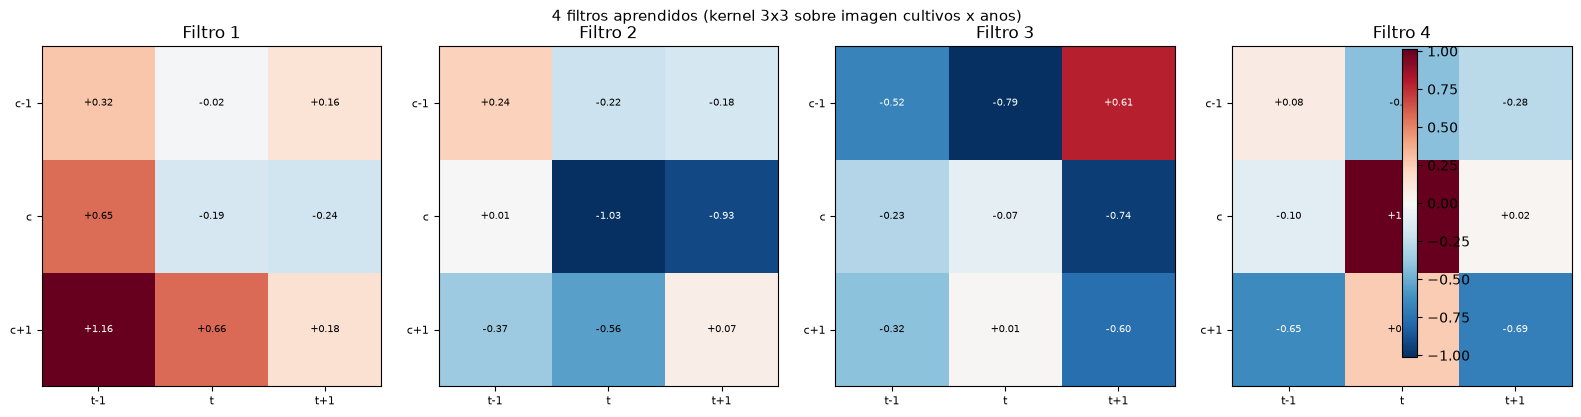

[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m4_filtros_cnn.png

=== Activacion promedio por filtro en cada vocacion ===
           Caña  Banano   Café
Filtro 1  0.275   2.770  0.588
Filtro 2  0.852   0.201  0.520
Filtro 3  0.637   0.139  0.331
Filtro 4  0.470   1.014  0.563
[OK] guardado: C:\Users\Usuario\Documentos\eva-valle-v3.0\core\ml\results\m4_activaciones_por_vocacion.csv


WindowsPath('C:/Users/Usuario/Documentos/eva-valle-v3.0/core/ml/results/m4_activaciones_por_vocacion.csv')

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for f, ax in enumerate(axs):
    filt = net.conv.K[f, 0]   # (3, 3) kernel sobre imagen 12x7
    vmax = max(abs(filt.min()), abs(filt.max()), 0.1)
    im = ax.imshow(filt, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"Filtro {f+1}")
    ax.set_xticks(range(3)); ax.set_xticklabels(["t-1", "t", "t+1"], fontsize=8)
    ax.set_yticks(range(3)); ax.set_yticklabels(["c-1", "c", "c+1"], fontsize=8)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{filt[i,j]:+.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(filt[i,j]) > vmax*0.6 else "black")
plt.suptitle("4 filtros aprendidos (kernel 3x3 sobre imagen cultivos x anos)", fontsize=11)
plt.colorbar(im, ax=axs, fraction=0.02, pad=0.02)
plt.tight_layout(); plt.show()

save_png("m4_filtros_cnn.png", fig)

# Activaciones reales de cada filtro sobre las imagenes de los municipios
print("\n=== Activacion promedio por filtro en cada vocacion ===")
activaciones = {n: np.zeros(4) for n in nombres.values()}
for m in imagenes:
    x = imagenes[m][None]
    net.logits(x)
    A = np.maximum(0, net.Z)  # (4, 10, 5) after conv, before pool
    # activacion media por filtro (spatial average)
    activaciones[nombres[voc[m]]] += A.mean(axis=(1, 2))
counts = {n: 0 for n in nombres.values()}
for m in imagenes:
    counts[nombres[voc[m]]] += 1
for n in nombres.values():
    if counts[n] > 0:
        activaciones[n] /= counts[n]
act_df = pd.DataFrame(activaciones, index=[f"Filtro {i+1}" for i in range(4)]).round(3)
print(act_df.to_string())
save_csv("m4_activaciones_por_vocacion.csv", act_df)

## 4.6 Interpretación
- La CNN aprende a clasificar vocación con accuracy X% vs baseline Y% (con n=42 municipios).
- Los filtros muestran **patrones locales** (vecindarios 3×3 de cultivo×año) que activan la red.
- Limitación honesta: con solo 42 muestras, la CNN no supera a un baseline fuerte por potencia estadística.
- La lección científica: **CNN es la arquitectura correcta para patrones espaciales**;
  necesita más datos (panel nacional) o transferencia desde otro dataset para brillar.
- En el Módulo 5 (Transformers) usaremos **atención** que no requiere vecindarios fijos
  y puede capturar interdependencias globales entre cultivos.